# 02 — Carbon pipeline

Produces every published number in the project. The dashboard, the databases
and the report read only what this notebook writes to `IIRS/Carbon_Stocks/results/`:

| File | Contents |
|---|---|
| `district_summary.json` | District totals, uncertainty, sensitivity runs, soil carbon by land class, the crop-yield cross-check and caveats |
| `model_metrics.json` | Random-forest validation under spatial-block cross-validation, with baselines and permutation importance |
| `carbon_cells.csv` / `carbon_cells.parquet` | One row per grid cell, keyed by `cell_id`, with each value and its source |
| `ndvi_monthly.json` | Monthly median NDVI over the grid |
| `fig_*.png` | Figures for the report |

**Census mode (default).** With `IIRS/Carbon_Stocks/v2/ludhiana_cells_v2.csv.gz`
from `00_gee_extraction.ipynb`, every cell is observed and district totals are
a census: Σ value × valid fraction × area inside the boundary.

**Sample mode (fallback).** Without the census table, the notebook works from
the 20,000-cell sample exports:

1. `SOC_mean` is SoilGrids **ocs**, the 0–30 cm organic carbon stock in t/ha
   (`01_data_quality`, Q10). Soil values in partially covered cells are divided
   by the valid fraction *w*, or the cell is marked no-data. No cell is deleted.
2. District totals come from design-based (survey) estimators: the sample
   behaves as a simple random sample of the grid (Q3), and the mapped soil
   area is known for every cell, so the stock is the sample density (ratio
   estimator) times that area.
3. Unsampled cells are filled by inverse-distance interpolation for the map
   only; the totals do not depend on it.

In both modes MOD17 NPP is scaled with its documented factor and checked
against an independent crop-yield estimate, and random-forest models are
trained and validated with spatial-block cross-validation (Section 5).

In [1]:
import json
import sys
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))
import config as C
import estimators as E

C.RESULTS.mkdir(exist_ok=True)
V2_FILE = C.DATA / "v2" / "ludhiana_cells_v2.csv.gz"
MODE = "v2-census" if V2_FILE.exists() else "v1-interim"
RUN_DATE = str(date.today())
print("Mode:", MODE)

Mode: v2-census


## 1. Load the grid and the sample

In [2]:
if MODE == "v1-interim":
    grid = C.load_grid()                      # 66,700 cells, keyed, area, soil QC
    sample = C.load_samples()                 # 20,000 cells: SoilGrids ocs (t/ha, diluted), NPP DN
    grid = grid.merge(sample, on="cell_id", how="left", validate="one_to_one")
    grid["sampled"] = grid["cell_id"].isin(sample["cell_id"])
    N, n = len(grid), int(grid["sampled"].sum())

    # Repair diluted soil bands for every cell (BD, sand, clay exist grid-wide; ocs only where sampled)
    for raw, out in [("bd_gcm3", "bd_rec"), ("sand_pct", "sand_rec"), ("clay_pct", "clay_rec"), ("ocs_raw_t_ha", "ocs_rec")]:
        grid[out] = C.undilute(grid[raw], grid["w_soil"])

    print(f"grid cells {N:,} | sampled {n:,} ({n / N:.1%})")
    print("soil status:", grid["soil_status"].value_counts().to_dict())
    print(f"grid area {grid.cell_area_ha.sum():,.0f} ha = {grid.cell_area_ha.sum() / C.OFFICIAL_AREA_HA:.1%} of the Census district area")
else:
    grid = pd.read_csv(V2_FILE)
    C.assert_unique(grid)
    geo = C.lattice_geometry(grid["grid_row"], grid["grid_col"])
    grid[["lon", "lat", "WKT"]] = geo.to_numpy()
    grid["lon"], grid["lat"] = grid["lon"].astype(float), grid["lat"].astype(float)
    grid["agri_class"] = (grid["cropland_frac"] >= 0.5).astype(int)
    grid["Ag/NonAg_m"] = grid["cropland_frac"]
    grid["DEM_mean"], grid["Slope_mean"] = grid["dem_m"], grid["slope_deg"]
    grid["soil_status"] = np.select([grid["soil_valid_frac"] >= 0.999, grid["soil_valid_frac"] > 0], ["full", "partial"], "nodata")
    # Totals are restricted to the district: weight each cell by the share inside the boundary
    grid["cell_area_full_ha"] = grid["cell_area_ha"]
    grid["cell_area_ha"] = grid["cell_area_ha"] * grid["in_district_frac"]
    grid["in_district_frac"] = 1.0          # already applied to cell_area_ha
    print(f"v2 cells {len(grid):,} | area inside boundary {grid.cell_area_ha.sum():,.0f} ha")

v2 cells 71,197 | area inside boundary 369,961 ha


## 2. Soil organic carbon stock (0–30 cm)

The stock density over a cell's valid soil is SoilGrids `ocs` 0–30 cm (t/ha),
the product's own stock prediction (it already accounts for bulk density and
coarse fragments). The cell's stock = ocs × valid fraction *w* × cell area.
Cells with no valid soil (mostly built-up land and water) contribute no soil
area and no stock; they are reported, not zero-filled into a mean.

**Census mode.** Σ ocs × valid fraction × area inside the boundary, for every
cell. Two boundaries are carried, so the boundary choice is visible as a
sensitivity. Rebuilding the stock from SOC × BD × 30 × (1 − coarse fraction)
is also reported: in Ludhiana it runs about 1.4× higher, because SoilGrids
predicts ocs with its own model rather than from the soc and bdod layers
(Poggio et al. 2021).

**Sample mode.** Mapped soil area A = Σ *w* × area is known for all cells. The
stock is the sample ratio R = Σ stock / Σ soil area times A, with SE = A × SE(R).

In [3]:
if MODE == "v1-interim":
    s = grid[grid["sampled"]].copy()
    s["dens"] = s["ocs_rec"]                                                 # tC per ha of valid soil
    s["y_stock"] = (s["dens"] * s["w_soil"] * s["cell_area_ha"]).fillna(0)  # tC in the cell (= ocs_raw x area)
    s["a_soil"] = s["w_soil"] * s["cell_area_ha"]

    A_soil = float((grid["w_soil"] * grid["cell_area_ha"]).sum())           # census, every cell
    stock = E.ratio_total(s["y_stock"], s["a_soil"], N, A_soil)
    density = E.srs_ratio(s["y_stock"], s["a_soil"], N)

    def variant(est):
        return E.scale(est, 1e-6)

    full_only = np.where(s["soil_status"] == "full", s["y_stock"], 0)
    reliable_only = np.where(s["soil_status"].eq("full") | s["w_reliable"], s["y_stock"], 0)
    sensitivity_soil = [
        {"variant": "Headline: ratio estimator x known soil area, partial cells divided by w", **variant(stock)},
        {"variant": "Expansion estimator (ignores the known soil area)", **variant(E.srs_total(s["y_stock"], N))},
        {"variant": "Only partial cells with w >= 0.5 repaired, rest dropped", **variant(E.srs_total(reliable_only, N))},
        {"variant": "All partially diluted cells dropped", **variant(E.srs_total(full_only, N))},
    ]
    soil_out = {
        "stock_mtc": E.scale(stock, 1e-6),
        "soil_area_ha": {"estimate": round(A_soil), "se": 0.0, "ci95": None, "n": int(N), "note": "census of every cell"},
        "mean_density_tc_ha": E.scale(density, 1, 3),
        "depth_cm": C.SOC_DEPTH_CM,
        "cells": grid["soil_status"].value_counts().to_dict(),
        "nodata_non_agricultural_share": round(float((grid.loc[grid.soil_status == "nodata", "agri_class"] == 0).mean()), 3),
        "method": "SoilGrids ocs 0-30 cm; ratio estimator from a random sample of 20,000 of 66,700 cells times the census soil area; partial-coverage values divided by w",
        "interval_covers": "sampling error only; see caveats for known biases that are not in the interval",
        "sensitivity": sensitivity_soil,
    }
else:
    tot = E.census_totals(grid)
    soil_out = {
        "stock_mtc": {"estimate": round(tot["soil_stock_tc"] / 1e6, 4), "se": None, "ci95": None},
        "soil_area_ha": {"estimate": round(tot["soil_area_ha"])},
        "mean_density_tc_ha": {"estimate": round(tot["soil_stock_tc"] / tot["soil_area_ha"], 3)},
        "depth_cm": C.SOC_DEPTH_CM,
        "method": "Census of every cell; SoilGrids ocs 0-30 cm (t/ha) x valid-soil fraction x area inside boundary",
    }
    computed = {"variant": "Rebuilt from SoilGrids SOC x BD x 30 cm x (1 - coarse fraction)",
                "estimate": round(tot["soil_stock_computed_tc"] / 1e6, 4)}
    check_col = f"in_{C.BOUNDARY_CHECK}"
    if check_col in grid:
        alt = E.census_totals(grid.assign(cell_area_ha=grid["cell_area_full_ha"], in_district_frac=grid[check_col]))
        soil_out["sensitivity"] = [
            {"variant": "Boundary: geoBoundaries ADM2 (headline)", "estimate": round(tot["soil_stock_tc"] / 1e6, 4), "area_ha": round(tot["area_in_district_ha"])},
            {"variant": "Boundary: Census 2011 (Datameet)", "estimate": round(alt["soil_stock_tc"] / 1e6, 4), "area_ha": round(alt["area_in_district_ha"])},
            computed,
        ]
    else:
        soil_out["sensitivity"] = [computed]
        npp_alt_mtc = round(alt["npp_flux_tc_yr"] / 1e6, 4)
    ok = grid["soil_valid_frac"] >= 0.999
    soil_out["ocs_crosscheck_ratio"] = round(float(
        (C.soc_stock_tc_ha(grid.loc[ok, "soc_030"], grid.loc[ok, "bdod_030"], 30, grid.loc[ok, "cfvo_030"] / 100)
         / grid.loc[ok, "ocs_030_t_ha"]).median()), 3)
    unc_file = C.RESULTS / "soilgrids_uncertainty.json"      # written by 05_soilgrids_uncertainty.ipynb
    if unc_file.exists():
        soil_out["soilgrids_uncertainty"] = json.loads(unc_file.read_text())[C.BOUNDARY_DEFAULT]
    else:
        soil_out["soilgrids_uncertainty"] = "not yet computed: run 05_soilgrids_uncertainty.ipynb"

print(json.dumps(soil_out, indent=2, default=str))

{
  "stock_mtc": {
    "estimate": 10.5371,
    "se": null,
    "ci95": null
  },
  "soil_area_ha": {
    "estimate": 342426
  },
  "mean_density_tc_ha": {
    "estimate": 30.772
  },
  "depth_cm": 30,
  "method": "Census of every cell; SoilGrids ocs 0-30 cm (t/ha) x valid-soil fraction x area inside boundary",
  "sensitivity": [
    {
      "variant": "Boundary: geoBoundaries ADM2 (headline)",
      "estimate": 10.5371,
      "area_ha": 369961
    },
    {
      "variant": "Boundary: Census 2011 (Datameet)",
      "estimate": 10.1832,
      "area_ha": 358482
    },
    {
      "variant": "Rebuilt from SoilGrids SOC x BD x 30 cm x (1 - coarse fraction)",
      "estimate": 14.4565
    }
  ],
  "ocs_crosscheck_ratio": 1.352,
  "soilgrids_uncertainty": {
    "headline_mean_mtc": 10.507,
    "median_q50_mtc": 8.205,
    "correlated_90pct_mtc": [
      2.173,
      27.685
    ],
    "independent_90pct_mtc": [
      10.457,
      10.558
    ],
    "soil_area_ha": 341413
  }
}


## 3. MOD17 NPP flux

`Agricultur` holds MOD17A3HGF DN. Flux (tC/ha/yr) = DN × 0.0001 kgC/m² × 10 =
DN / 1000. Negative values are kept: they are the product's own output, and
clipping them to zero would bias the total upwards. Cells where the product
has no value (82% non-agricultural) are outside its domain, not zero.

In [4]:
if MODE == "v1-interim":
    s["npp_valid"] = s["npp_dn"].notna()
    s["flux_tc_ha_yr"] = s["npp_dn"] * C.NPP_DN_TO_TC_HA_YR
    s["y_flux"] = (s["flux_tc_ha_yr"] * s["cell_area_ha"]).fillna(0)
    s["a_flux"] = np.where(s["npp_valid"], s["cell_area_ha"], 0.0)

    flux = E.srs_total(s["y_flux"], N)
    flux_area = E.srs_total(s["a_flux"], N)
    flux_rate = E.srs_ratio(s["y_flux"], s["a_flux"], N)
    agri = s["agri_class"] == 1

    sensitivity_npp = [
        {"variant": "Headline: DN / 1000, negatives kept", **E.scale(flux, 1e-6)},
        {"variant": "Negatives clipped to zero", **E.scale(E.srs_total((s["flux_tc_ha_yr"].clip(lower=0) * s["cell_area_ha"]).fillna(0), N), 1e-6)},
        {"variant": "Agricultural cells only", **E.scale(E.srs_total(np.where(agri, s["y_flux"], 0), N), 1e-6)},
        {"variant": "Old conversion DN / 100 (wrong by 10x), negatives clipped", **E.scale(E.srs_total((s["npp_dn"].clip(lower=0) / 100 * s["cell_area_ha"]).fillna(0), N), 1e-6)},
    ]
    npp_out = {
        "flux_mtc_per_year": E.scale(flux, 1e-6),
        "domain_area_ha": E.scale(flux_area, 1, 0),
        "mean_rate_tc_ha_yr": E.scale(flux_rate, 1, 3),
        "mean_rate_agricultural_tc_ha_yr": round(float(s.loc[agri & s.npp_valid, "flux_tc_ha_yr"].mean()), 3),
        "negative_share_agricultural": round(float((s.loc[agri & s.npp_valid, "npp_dn"] < 0).mean()), 3),
        "conversion": C.AG_FORMULA,
        "method": "Expansion estimator from the same random sample; MOD17 DN scaled per product specification",
        "sensitivity": sensitivity_npp,
    }
else:
    npp_out = {
        "flux_mtc_per_year": {"estimate": round(tot["npp_flux_tc_yr"] / 1e6, 4), "se": None, "ci95": None},
        "domain_area_ha": {"estimate": round(tot["npp_area_ha"])},
        "mean_rate_tc_ha_yr": {"estimate": round(tot["npp_flux_tc_yr"] / tot["npp_area_ha"], 3)},
        "conversion": "npp_gc_m2_yr / 100 (scaled inside Earth Engine)",
        "method": "Census of every cell, area inside boundary",
    }
    if "npp_alt_mtc" in globals():
        npp_out["sensitivity"] = [
            {"variant": f"Boundary: {C.BOUNDARY_DEFAULT} (headline)", "estimate": round(tot["npp_flux_tc_yr"] / 1e6, 4)},
            {"variant": f"Boundary: {C.BOUNDARY_CHECK}", "estimate": npp_alt_mtc}]
print(json.dumps(npp_out, indent=2, default=str))

{
  "flux_mtc_per_year": {
    "estimate": 0.3353,
    "se": null,
    "ci95": null
  },
  "domain_area_ha": {
    "estimate": 351622
  },
  "mean_rate_tc_ha_yr": {
    "estimate": 0.954
  },
  "conversion": "npp_gc_m2_yr / 100 (scaled inside Earth Engine)",
  "method": "Census of every cell, area inside boundary"
}


### Independent check: crop NPP from harvested yield

Ludhiana is a rice–wheat double-crop district. Carbon in harvested grain,
residue and roots can be computed from reported yields with IPCC (2019)
Vol. 4 Table 11.1a factors. This is a lower bound on true NPP.

| Input | Wheat | Rice (paddy) | Source |
|---|---|---|---|
| Area (ha) | 245,200 (2023-24) | 256,600 (2024) | Tribune India, 23 Apr 2024; 5 Jan 2025 (district agriculture department figures) |
| Yield (t/ha, as harvested) | 5.000 | 7.014 | same |
| Dry-matter fraction | 0.89 | 0.89 | IPCC 2019 Table 11.1a |
| Above-ground residue : yield | 1.3 | 1.4 | IPCC 2019 Table 11.1a (R_AG) |
| Root : shoot | 0.23 ± 41% | 0.16 ± 35% | IPCC 2019 Table 11.1a (RS) |
| Carbon fraction of dry matter | 0.42–0.47 | 0.42–0.47 | assumption, uniform range |

The wheat yield is a preliminary in-season figure; a 10% relative SD is used
for both yields and 20% for the residue ratios.

In [5]:
CROPS = {
    "wheat": {"area_ha": 245_200, "yield_t_ha": 5.000, "yield_rel_sd": 0.10, "dry_frac": 0.89,
              "residue_ratio": 1.3, "residue_rel_sd": 0.20, "root_shoot": 0.23, "root_shoot_rel_sd": 0.41},
    "rice":  {"area_ha": 256_600, "yield_t_ha": 7.014, "yield_rel_sd": 0.10, "dry_frac": 0.89,
              "residue_ratio": 1.4, "residue_rel_sd": 0.20, "root_shoot": 0.16, "root_shoot_rel_sd": 0.35},
}
crop = E.crop_npp_monte_carlo(CROPS, seed=C.RANDOM_STATE)
mod17 = npp_out["flux_mtc_per_year"]["estimate"]
crop["mod17_over_crop_ratio"] = round(mod17 / crop["total_mtc_median"], 3)
# Area-independent view: per hectare of double-cropped land, one year
crop["crop_tc_ha_yr_double_cropped"] = round(sum(v["tc_ha_median"] for v in crop["per_crop"].values()), 2)
if MODE == "v1-interim":
    crop["mod17_agricultural_tc_ha_yr"] = npp_out["mean_rate_agricultural_tc_ha_yr"]
crop["comparability_note"] = ("MOD17 is totalled over the grid's product domain (the grid covers ~95% of the district) "
                              "while crop areas are district-wide; MOD17 is 2024 while yields are "
                              "2023-24 (wheat) and 2024 (paddy). Neither changes the order-of-magnitude gap.")
crop["inputs"] = CROPS
print(f"Crop-yield NPP (rice + wheat, lower bound): {crop['total_mtc_median']:.2f} MtC/yr "
      f"(90% range {crop['total_mtc_p05_p95'][0]:.2f}-{crop['total_mtc_p05_p95'][1]:.2f})")
for k, v in crop["per_crop"].items():
    print(f"  {k:5s} {v['tc_ha_median']:.2f} tC/ha per season (90%: {v['tc_ha_p05_p95'][0]:.2f}-{v['tc_ha_p05_p95'][1]:.2f})")
print(f"MOD17 (scaled per specification): {mod17:.3f} MtC/yr = {crop['mod17_over_crop_ratio']:.1%} of the crop-yield lower bound")
print(f"Per hectare per year: crops >= {crop['crop_tc_ha_yr_double_cropped']} tC/ha/yr on double-cropped land; "
      f"MOD17 on agricultural cells {crop.get('mod17_agricultural_tc_ha_yr')} tC/ha/yr")

Crop-yield NPP (rice + wheat, lower bound): 3.34 MtC/yr (90% range 2.70-4.07)
  wheat 5.55 tC/ha per season (90%: 4.10-7.26)
  rice  7.66 tC/ha per season (90%: 5.72-9.97)
MOD17 (scaled per specification): 0.335 MtC/yr = 10.1% of the crop-yield lower bound
Per hectare per year: crops >= 13.2 tC/ha/yr on double-cropped land; MOD17 on agricultural cells None tC/ha/yr


**Reading this result.** MOD17 captures roughly a tenth of the carbon that
demonstrably passes through Ludhiana's crops each year. MOD17 is therefore not
fit for estimating crop carbon flux in this irrigated double-cropped
landscape; it is reported as the product gives it, with the unit conversion
fixed by the product specification. The yield-based estimate above, or a
crop-specific light-use-efficiency model, is the better basis for crop flux.

## 4. Per-cell map

Every cell gets a value and a `*_source` label. In census mode every value is
observed. In sample mode, unsampled cells are filled by inverse-distance
weighting (k = 8, power 2) from sampled cells, validated with random folds
because the unsampled cells are interleaved with the sample at the same
spacing.

In [6]:
interp_metrics = {}
if MODE == "v1-interim":
    xy_all = E.to_metres(grid["lon"], grid["lat"])
    samp = grid["sampled"].to_numpy()

    # ocs: interpolate repaired values from sampled cells whose repair is reliable (w >= 0.5)
    soc_src = samp & grid["ocs_rec"].notna().to_numpy() & (grid["soil_status"].eq("full") | grid["w_reliable"]).to_numpy()
    interp_metrics["ocs_t_ha"] = E.idw_cv(xy_all[soc_src], grid.loc[soc_src, "ocs_rec"])
    grid["soc_stock_tc_ha"] = grid["ocs_rec"]
    fill = ~samp & (grid["soil_status"] != "nodata").to_numpy()
    grid.loc[fill, "soc_stock_tc_ha"] = E.idw(xy_all[soc_src], grid.loc[soc_src, "ocs_rec"], xy_all[fill])
    grid["soc_gkg"] = np.nan                  # the sample export has no SOC content column
    grid["soc_source"] = np.select([grid["soil_status"] == "nodata", samp], ["no soil data", "observed"], "interpolated")

    # NPP: interpolate the validity mask and the DN, from sampled cells
    npp_ok = samp & grid["npp_dn"].notna().to_numpy()
    interp_metrics["npp_gc_m2_yr"] = E.idw_cv(xy_all[npp_ok], grid.loc[npp_ok, "npp_dn"] * C.NPP_DN_TO_GC_M2_YR)
    valid_p = E.idw(xy_all[samp], grid.loc[samp, "npp_dn"].notna().astype(float), xy_all[~samp])
    grid["npp_dn_map"] = grid["npp_dn"]
    est = E.idw(xy_all[npp_ok], grid.loc[npp_ok, "npp_dn"], xy_all[~samp])
    grid.loc[~samp, "npp_dn_map"] = np.where(valid_p >= 0.5, est, np.nan)
    grid["npp_source"] = np.where(samp, np.where(grid["npp_dn"].notna(), "observed", "outside MOD17 domain"),
                                  np.where(grid["npp_dn_map"].notna(), "interpolated", "outside MOD17 domain"))

    grid["bd_gcm3_rec"] = grid["bd_rec"]
    grid["npp_flux_tc_ha_yr"] = grid["npp_dn_map"] * C.NPP_DN_TO_TC_HA_YR
else:
    grid["soc_gkg"], grid["bd_gcm3_rec"] = grid["soc_030"], grid["bdod_030"]
    grid["w_soil"] = grid["soil_valid_frac"]
    grid["soc_stock_tc_ha"] = grid["ocs_030_t_ha"]
    grid["npp_flux_tc_ha_yr"] = grid["npp_gc_m2_yr"] / 100
    grid["soc_source"] = np.where(grid["ocs_030_t_ha"].notna(), "observed", "no soil data")
    grid["npp_source"] = np.where(grid["npp_gc_m2_yr"].notna(), "observed", "outside MOD17 domain")

grid["soc_stock_tc"] = (grid["soc_stock_tc_ha"] * grid["w_soil"] * grid["cell_area_ha"]).fillna(0)
# census: only the MOD17-valid share of a cell carries flux, as in the census headline
npp_share = grid["npp_valid_frac"] if MODE == "v2-census" else 1.0
grid["npp_flux_tc_yr"] = (grid["npp_flux_tc_ha_yr"] * grid["cell_area_ha"] * npp_share).fillna(0)

for k, m in interp_metrics.items():
    print(f"IDW {k:8s} R2 {m['r2']:.3f}  RMSE {m['rmse']:.3f}  MAE {m['mae']:.3f}  bias {m['bias']:+.4f}  (n={m['n']:,})")
print(f"\nmap sum, soil stock: {grid.soc_stock_tc.sum() / 1e6:.4f} MtC   (headline: {soil_out['stock_mtc']['estimate']})")
print(f"map sum, NPP flux:   {grid.npp_flux_tc_yr.sum() / 1e6:.4f} MtC/yr (headline: {npp_out['flux_mtc_per_year']['estimate']})")


map sum, soil stock: 10.5371 MtC   (headline: 10.5371)
map sum, NPP flux:   0.3353 MtC/yr (headline: 0.3353)


The map sums are a consistency check, not the estimate: totals always come from
the design-based estimator. The soil map sum falls inside its interval. The NPP
map sum runs a few per cent high because inverse-distance weighting smooths a
field that mixes positive and negative values, pulling isolated negative cells
towards their positive neighbours.

In [7]:
if MODE == "v1-interim":
    for name, mapped, est in [("soil stock (MtC)", grid.soc_stock_tc.sum() / 1e6, soil_out["stock_mtc"]),
                              ("NPP flux (MtC/yr)", grid.npp_flux_tc_yr.sum() / 1e6, npp_out["flux_mtc_per_year"])]:
        lo, hi = est["ci95"]
        print(f"{name:18s} map {mapped:.4f} | design {est['estimate']} [{lo}, {hi}] | "
              f"{'inside' if lo <= mapped <= hi else 'outside by %+.1f%%' % (100 * (mapped / est['estimate'] - 1))}")

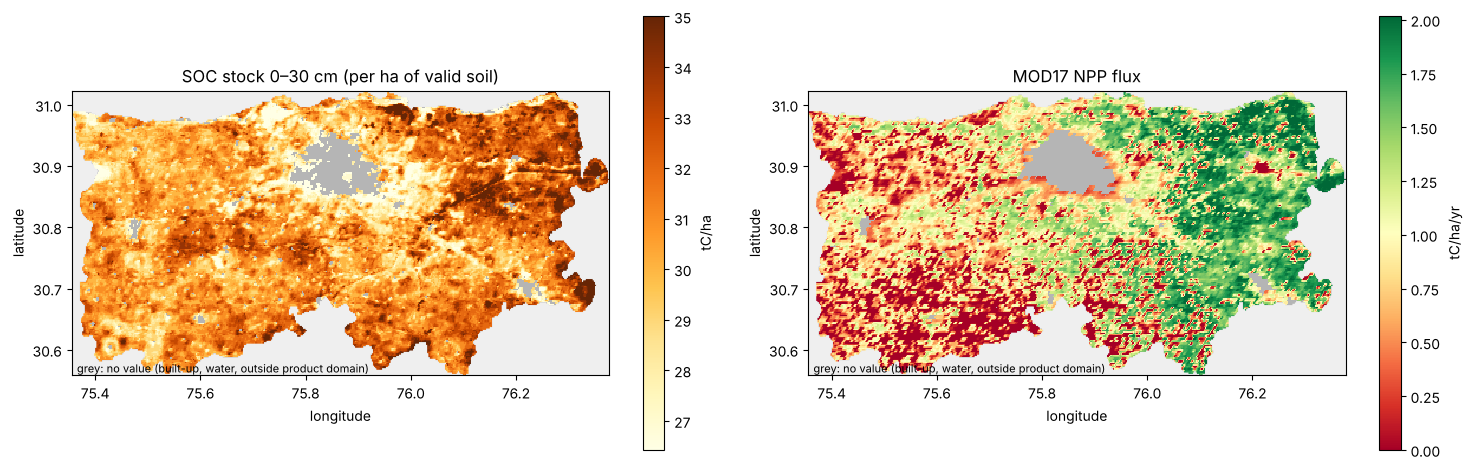

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
r0, c0 = grid["grid_row"].min(), grid["grid_col"].min()
shape = (grid["grid_row"].max() - r0 + 1, grid["grid_col"].max() - c0 + 1)
extent = [c0 * C.GRID_STEP_DEG, (c0 + shape[1]) * C.GRID_STEP_DEG, r0 * C.GRID_STEP_DEG, (r0 + shape[0]) * C.GRID_STEP_DEG]
for a, col, title, cmap, unit in [
    (ax[0], "soc_stock_tc_ha", "SOC stock 0–30 cm (per ha of valid soil)", "YlOrBr", "tC/ha"),
    (ax[1], "npp_flux_tc_ha_yr", "MOD17 NPP flux", "RdYlGn", "tC/ha/yr"),
]:
    img = np.full(shape, np.nan)
    img[grid["grid_row"] - r0, grid["grid_col"] - c0] = grid[col]
    outside = np.ones(shape, bool)
    outside[grid["grid_row"] - r0, grid["grid_col"] - c0] = False
    cm = plt.get_cmap(cmap).copy(); cm.set_bad("#b5b5b5")
    v = grid[col].dropna()
    im = a.imshow(np.ma.masked_invalid(img), origin="lower", extent=extent, cmap=cm, interpolation="nearest",
                  vmin=np.percentile(v, 2), vmax=np.percentile(v, 98))
    a.imshow(np.ma.masked_where(~outside, np.ones(shape)), origin="lower", extent=extent, cmap="Greys", vmin=0, vmax=8)
    a.set_title(title); a.set_aspect(1 / np.cos(np.radians(30.8))); a.set_xlabel("longitude"); a.set_ylabel("latitude")
    plt.colorbar(im, ax=a, shrink=0.7, label=unit)
    a.text(0.01, 0.01, "grey: no value (built-up, water, outside product domain)", transform=a.transAxes, fontsize=8)
plt.tight_layout(); plt.savefig(C.RESULTS / "fig_maps.png", dpi=130); plt.show()

## 5. Random forest models

Two random forests are trained on a 20,000-cell random sample and evaluated by
5-fold cross-validation over an 8 × 8 grid of geographic blocks, so that test
cells are never neighbours of training cells (Roberts et al., 2017). Each is
compared with two baselines: the training-fold mean, and a forest given only
longitude and latitude. Feature importance is permutation importance on the
held-out folds.

* **Soil organic carbon** (SoilGrids 0–30 cm stock, t/ha), from environmental
  covariates that are independent of SoilGrids: terrain, land cover and twelve
  monthly Sentinel-2 NDVI composites. A second run adds SoilGrids' own texture,
  bulk density and coarse-fragment layers; because those share the target's
  model, that run measures agreement within one product rather than predictive
  skill, and is reported for comparison only.
* **Net primary production** (MOD17, gC/m²/yr), from the same environmental
  covariates.

The district totals do not depend on these models: every cell is observed
directly (Section 2). The models show how much of the spatial pattern the
covariates explain.


In [9]:
def make_rf(n=300):
    return RandomForestRegressor(n_estimators=n, min_samples_leaf=5, max_features=0.33, n_jobs=-1,
                                 random_state=C.RANDOM_STATE)


def make_gbm():
    return HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05, max_leaf_nodes=31, min_samples_leaf=40,
                                         l2_regularization=1.0, random_state=C.RANDOM_STATE)


def spatial_eval(d, feats, target, n_repeats=2):
    """Random forest under spatial-block CV, with baselines, a gradient-boosting comparison and
    permutation importance per feature family (a covariate and its neighbourhood means together)."""
    X, y = d[feats].to_numpy(dtype=float), d[target].to_numpy(dtype=float)
    groups = C.spatial_blocks(d["lon"], d["lat"])
    families = pd.Series([C.feature_family(f) for f in feats])
    fam_idx = {fam: np.where(families == fam)[0] for fam in families.unique()}
    pred, gbm, base, coord = (np.empty_like(y) for _ in range(4))
    imp = {fam: 0.0 for fam in fam_idx}
    XY = d[["lon", "lat"]].to_numpy()
    rng = np.random.default_rng(C.RANDOM_STATE)
    for tr, te in GroupKFold(C.N_FOLDS).split(X, y, groups):
        m = make_rf().fit(X[tr], y[tr]); pred[te] = m.predict(X[te])
        r2_fold = r2_score(y[te], pred[te])
        for fam, cols in fam_idx.items():                  # grouped permutation importance on the held-out fold
            drops = []
            for _ in range(n_repeats):
                Xp = X[te].copy(); perm = rng.permutation(len(te))
                Xp[:, cols] = Xp[perm][:, cols]
                drops.append(r2_fold - r2_score(y[te], m.predict(Xp)))
            imp[fam] += np.mean(drops) / C.N_FOLDS
        gbm[te] = make_gbm().fit(X[tr], y[tr]).predict(X[te])
        base[te] = y[tr].mean()
        coord[te] = make_rf(200).fit(XY[tr], y[tr]).predict(XY[te])
    score = lambda p, name: {"model": name, "r2": round(r2_score(y, p), 4),
                             "rmse": round(mean_squared_error(y, p) ** 0.5, 4), "mae": round(mean_absolute_error(y, p), 4)}
    imp = pd.Series(imp).sort_values(ascending=False)
    return {"n": int(len(y)), "n_features": len(feats), "target_sd": round(float(y.std()), 4),
            "validation": f"{C.N_FOLDS}-fold GroupKFold over {C.N_BLOCKS}x{C.N_BLOCKS} geographic blocks",
            "models": [score(pred, "Random forest"), score(gbm, "Gradient boosting"),
                       score(coord, "Coordinates only"), score(base, "Training mean")],
            "permutation_importance": [{"feature": k, "importance": round(float(v), 4)} for k, v in imp.items()]}

if MODE == "v1-interim":
    ml = grid[grid["sampled"] & (grid["soil_status"] == "full")].copy()
    SOC_FEATS = ["agri_class", "DEM_mean", "Slope_mean", "sand_rec", "clay_rec", "bd_rec"]
    soc_ml = spatial_eval(ml, SOC_FEATS, "ocs_rec")
    soc_ml["unit"] = "t/ha (SoilGrids ocs 0-30 cm)"

    nd = C.load_ndvi(grid)
    npp_ml_df = grid[grid["sampled"] & grid["npp_dn"].notna()].merge(nd, on="cell_id", how="left")
    npp_ml_df["npp_gc_m2_yr"] = npp_ml_df["npp_dn"] * C.NPP_DN_TO_GC_M2_YR
    NPP_FEATS = ["agri_class", "DEM_mean", "Slope_mean", "Kharif_pea", "Rabi_Peak_", "Kharif_Lud", "NDWI_Rabi_"] + C.NDVI_COLS
    npp_ml = spatial_eval(npp_ml_df, NPP_FEATS, "npp_gc_m2_yr")
    npp_ml["unit"] = "gC/m2/yr"
    npp_ml["excluded_position_proxies"] = C.POSITION_PROXIES

    for name, r in [("SOC", soc_ml), ("NPP", npp_ml)]:
        print(f"\n{name} (n={r['n']:,}, target sd {r['target_sd']} {r['unit']})")
        print(pd.DataFrame(r["models"]).to_string(index=False))
        print("top importance:", [(d["feature"], d["importance"]) for d in r["permutation_importance"][:5]])
else:
    ND = [c for c in grid.columns if c.startswith("NDVI_")]
    LOCAL = ["dem_m", "slope_deg", "cropland_frac", "builtup_frac", "tree_frac", "water_frac"] + ND
    SOILP = ["sand_030", "clay_030", "bdod_030", "cfvo_030"]
    feat = grid.copy()
    feat[ND] = feat[ND].fillna(feat[ND].median())
    nd = feat[ND].to_numpy()
    feat["ndvi_max"], feat["ndvi_mean"], feat["ndvi_std"] = nd.max(axis=1), nd.mean(axis=1), nd.std(axis=1)
    feat["ndvi_kharif_peak"] = feat[["NDVI_Aug24", "NDVI_Sep24", "NDVI_Oct24"]].max(axis=1)
    feat["ndvi_rabi_peak"] = feat[["NDVI_Jan25", "NDVI_Feb25", "NDVI_Mar25"]].max(axis=1)
    feat["ndvi_amplitude"] = feat["ndvi_max"] - nd.min(axis=1)
    STATS = ["ndvi_max", "ndvi_mean", "ndvi_std", "ndvi_kharif_peak", "ndvi_rabi_peak", "ndvi_amplitude"]
    feat["rot_ne"], feat["rot_nw"] = feat["lon"] + feat["lat"], feat["lon"] - feat["lat"]
    COORDS = ["lon", "lat", "rot_ne", "rot_nw"]
    ENV = LOCAL + STATS
    feat = pd.concat([feat, C.neighbourhood_means(feat, ENV + SOILP)], axis=1)
    ENV_ALL = ENV + [f"{c}_f{k}" for c in ENV for k in C.FOCAL_WINDOWS] + COORDS
    SOIL_ALL = SOILP + [f"{c}_f{k}" for c in SOILP for k in C.FOCAL_WINDOWS]
    inside = feat[feat["cell_area_ha"] > 0]

    soc_cells = inside[(inside["soil_valid_frac"] >= 0.999) & inside["ocs_030_t_ha"].notna()]
    soc_d = soc_cells.sample(min(20_000, len(soc_cells)), random_state=C.RANDOM_STATE)
    soc_ml = spatial_eval(soc_d, ENV_ALL, "ocs_030_t_ha")
    soc_ml["unit"] = "t/ha (SoilGrids 0-30 cm stock)"
    soc_ml["features"] = "terrain, land cover, monthly NDVI and NDVI statistics, each with 0.7-9 km neighbourhood means; coordinates"
    soc_with_soilgrids = spatial_eval(soc_d, ENV_ALL + SOIL_ALL, "ocs_030_t_ha")
    soc_ml["with_soilgrids_properties"] = {k: soc_with_soilgrids[k] for k in ["models", "permutation_importance"]}

    npp_cells = inside[inside["npp_gc_m2_yr"].notna() & (inside["npp_valid_frac"] >= 0.999)]
    npp_d = npp_cells.sample(min(20_000, len(npp_cells)), random_state=C.RANDOM_STATE)
    npp_ml = spatial_eval(npp_d, ENV_ALL, "npp_gc_m2_yr")
    npp_ml["unit"] = "gC/m2/yr"
    npp_ml["features"] = soc_ml["features"]

    # Feature-set ablation for the report (random forest, same folds)
    def rf_r2(d, feats, target):
        X, y = d[feats].to_numpy(float), d[target].to_numpy(float)
        p = np.empty_like(y)
        for tr, te in GroupKFold(C.N_FOLDS).split(X, y, C.spatial_blocks(d["lon"], d["lat"])):
            p[te] = make_rf().fit(X[tr], y[tr]).predict(X[te])
        return round(r2_score(y, p), 4)
    ablation_sets = {"cell covariates only": LOCAL,
                     "+ NDVI statistics": ENV,
                     "+ neighbourhood means": ENV + [f"{c}_f{k}" for c in ENV for k in C.FOCAL_WINDOWS],
                     "+ coordinates (full model)": ENV_ALL}
    for r, d, t in [(soc_ml, soc_d, "ocs_030_t_ha"), (npp_ml, npp_d, "npp_gc_m2_yr")]:
        r["ablation"] = [{"features": k, "r2": (r["models"][0]["r2"] if k.endswith("(full model)") else rf_r2(d, f, t))}
                         for k, f in ablation_sets.items()]

    for name, r in [("SOC (environmental covariates)", soc_ml), ("SOC (+ SoilGrids properties)", soc_with_soilgrids),
                    ("NPP", npp_ml)]:
        print(f"\n{name} (n={r['n']:,}, {r['n_features']} features, target sd {r['target_sd']})")
        print(pd.DataFrame(r["models"]).to_string(index=False))
        print("top importance:", [(d["feature"], d["importance"]) for d in r["permutation_importance"][:6]])
        if "ablation" in r:
            print("ablation:", [(a["features"], a["r2"]) for a in r["ablation"]])



SOC (environmental covariates) (n=20,000, 124 features, target sd 1.8921)
            model      r2   rmse    mae
    Random forest  0.4410 1.4146 1.0765
Gradient boosting  0.4314 1.4268 1.0928
 Coordinates only  0.3193 1.5611 1.1737
    Training mean -0.0160 1.9072 1.4641
top importance: [('ndvi_mean', 0.0824), ('coordinates', 0.0668), ('NDVI_Nov24', 0.0532), ('dem_m', 0.0359), ('tree_frac', 0.0234), ('water_frac', 0.0151)]
ablation: [('cell covariates only', 0.2587), ('+ NDVI statistics', 0.2585), ('+ neighbourhood means', 0.4346), ('+ coordinates (full model)', 0.441)]

SOC (+ SoilGrids properties) (n=20,000, 144 features, target sd 1.8921)
            model      r2   rmse    mae
    Random forest  0.4695 1.3781 1.0479
Gradient boosting  0.4622 1.3876 1.0603
 Coordinates only  0.3193 1.5611 1.1737
    Training mean -0.0160 1.9072 1.4641
top importance: [('bdod_030', 0.072), ('ndvi_mean', 0.0679), ('coordinates', 0.0573), ('clay_030', 0.0443), ('NDVI_Nov24', 0.0376), ('sand_030', 0.

## 6. Write results

In [10]:
caveats = [
    "The confidence intervals cover sampling error only. Known biases outside them: grid covering about 95% of the district, and cells with BD 1.40-1.50 treated as undiluted.",
    "Soil stocks are SoilGrids 2.0 ocs model predictions, not field measurements. " + (
        "SoilGrids' own 90% prediction interval, summed with fully correlated errors, puts the district stock at {}-{} MtC (05_soilgrids_uncertainty.ipynb). ".format(*soil_out["soilgrids_uncertainty"]["correlated_90pct_mtc"])
        if isinstance(soil_out.get("soilgrids_uncertainty"), dict) else "SoilGrids' own uncertainty is not yet propagated. ")
    + "Rebuilding the stock from SoilGrids SOC x BD instead gives about 1.4x more.",
    "The grid covers {:.1%} of the Census 2011 district area and is not clipped to an official boundary.".format(grid["cell_area_ha"].sum() / C.OFFICIAL_AREA_HA),
    "MOD17 NPP captures about {:.0%} of the crop-yield lower bound{}; it is not fit for crop carbon flux here.".format(
        crop["mod17_over_crop_ratio"],
        " and is negative in about a fifth of agricultural cells (year unrecorded)" if MODE == "v1-interim"
        else f" in {int(json.loads((C.DATA / 'v2' / 'manifest.json').read_text())['npp']['year'])}"),
    "Soil stock (tC) and NPP flux (tC/yr) have different dimensions and are never summed.",
    "Neither figure is a carbon-credit quantity: no baseline, additionality, permanence or field verification.",
]
if MODE == "v2-census":
    caveats = [c for c in caveats if "v1" not in c and "Coarse" not in c and "grid covers" not in c and "intervals cover" not in c]

# Soil carbon and NPP by land class (from the per-cell table; sums equal the headline in census mode)
names = {1: "Agricultural", 0: "Non-agricultural"}
by_class = []
for k, g in grid.groupby("agri_class"):
    soil_ha = float((g["w_soil"] * g["cell_area_ha"]).sum())
    by_class.append({"land_class": names.get(int(k), str(k)), "cells": int(len(g)),
                     "area_ha": round(float(g["cell_area_ha"].sum())),
                     "soil_stock_mtc": round(float(g["soc_stock_tc"].sum()) / 1e6, 4),
                     "soc_density_tc_ha": round(float(g["soc_stock_tc"].sum()) / soil_ha, 2) if soil_ha else None,
                     "npp_flux_mtc_yr": round(float(g["npp_flux_tc_yr"].sum()) / 1e6, 4)})
soil_out["by_land_class"] = by_class

summary = {
    "mode": MODE, "run_date": RUN_DATE, "status": "provisional" if MODE == "v1-interim" else "census",
    "district": "Ludhiana, Punjab, India",
    "grid": {"cells": int(len(grid)), "area_ha": round(float(grid["cell_area_ha"].sum()), 1),
             "official_area_ha": C.OFFICIAL_AREA_HA,
             "coverage_of_official_area": round(float(grid["cell_area_ha"].sum() / C.OFFICIAL_AREA_HA), 4),
             "sampled_cells": int(grid["sampled"].sum()) if "sampled" in grid else None,
             "agri_cells": int((grid["agri_class"] == 1).sum()) if "agri_class" in grid else None},
    "soil": soil_out, "npp": npp_out, "crop_yield_crosscheck": crop,
    "formulas": {"soil": C.BG_FORMULA, "npp": C.AG_FORMULA},
    "caveats": caveats,
}
metrics = {"mode": MODE, "run_date": RUN_DATE, "interpolation": interp_metrics, "soc_experiment": soc_ml, "npp_experiment": npp_ml}

# Monthly NDVI summary for the dashboard (cells whose NDVI can be attributed)
if MODE == "v1-interim":
    nd_all = C.load_ndvi(grid)
else:
    nd_all = grid[["cell_id"] + [c for c in grid.columns if c.startswith("NDVI_")]]
season = {"Jun": "Kharif", "Jul": "Kharif", "Aug": "Kharif", "Sep": "Kharif", "Oct": "Kharif",
          "Nov": "Rabi", "Dec": "Rabi", "Jan": "Rabi", "Feb": "Rabi", "Mar": "Rabi", "Apr": "Rabi", "May": "Fallow"}
ndvi_cols = [c for c in nd_all.columns if c.startswith("NDVI_")]
ndvi_monthly = [{"month": f"{c[5:8]} {c[8:]}", "sort_order": i, "season": season.get(c[5:8], ""),
                 "median_ndvi": round(float(nd_all[c].median()), 4),
                 "cells_with_value": int(nd_all[c].notna().sum()),
                 "missing_share": round(float(nd_all[c].isna().mean()), 4)}
                for i, c in enumerate(ndvi_cols)]
(C.RESULTS / "ndvi_monthly.json").write_text(json.dumps(ndvi_monthly, indent=2))

(C.RESULTS / "district_summary.json").write_text(json.dumps(summary, indent=2, default=float))
(C.RESULTS / "model_metrics.json").write_text(json.dumps(metrics, indent=2, default=float))

keep = ["cell_id", "Grid_ID", "grid_row", "grid_col", "lon", "lat", "cell_area_ha", "agri_class", "Ag/NonAg_m",
        "DEM_mean", "Slope_mean", "soil_status", "w_soil", "w_reliable", "bd_gcm3_rec", "soc_gkg", "soc_source",
        "soc_stock_tc_ha", "soc_stock_tc", "npp_flux_tc_ha_yr", "npp_source", "npp_flux_tc_yr", "WKT"]
out = grid[[c for c in keep if c in grid.columns]]
C.assert_unique(out).to_csv(C.RESULTS / "carbon_cells.csv", index=False, float_format="%.5g")
# Compact copy for the public Streamlit app (committed; the CSV is git-ignored)
app_cols = [c for c in keep if c != "WKT"] + [c for c in ["cropland_frac", "builtup_frac", "npp_valid_frac"] if c in grid]
app = grid[[c for c in app_cols if c in grid.columns]].copy()
for col in app.select_dtypes("float64"):
    app[col] = app[col].astype("float32")
app.to_parquet(C.RESULTS / "carbon_cells.parquet", index=False, compression="zstd")
print("Wrote district_summary.json, model_metrics.json, ndvi_monthly.json, carbon_cells.csv", f"({len(out):,} cells)")
print(f"\nSOC stock  : {soil_out['stock_mtc']['estimate']} MtC  95% CI {soil_out['stock_mtc'].get('ci95')}")
print(f"NPP flux   : {npp_out['flux_mtc_per_year']['estimate']} MtC/yr  95% CI {npp_out['flux_mtc_per_year'].get('ci95')}")

Wrote district_summary.json, model_metrics.json, ndvi_monthly.json, carbon_cells.csv (71,197 cells)

SOC stock  : 10.5371 MtC  95% CI None
NPP flux   : 0.3353 MtC/yr  95% CI None
